In [40]:
import pandas as pd
from sqlalchemy import create_engine

# Simulazione dati PCF (Product Carbon Footprint)
data_emissioni = {
    'id': ['A1', 'A2', 'B1', 'C1', 'C2', 'D1'],
    'year': [2017, 2017, 2017, 2017, 2016, 2017],
    'product_name': ['Smartphone', 'Laptop', 'T-shirt', 'Car', 'Truck', 'Bread'],
    'company': ['TechCo', 'TechCo', 'FashionInc', 'AutoGroup', 'AutoGroup', 'FoodCorp'],
    'industry_group': ['Technology', 'Technology', 'Textiles', 'Automotive', 'Automotive', 'Food'],
    'carbon_footprint_pcf': [150.55, 320.12, 12.40, 5500.80, 12000.50, 1.25]
}

engine = create_engine('sqlite://')
pd.DataFrame(data_emissioni).to_sql('product_emissions', engine, index=False)

print("Database Progetto E pronto: tabella 'product_emissions' caricata.")

Database Progetto E pronto: tabella 'product_emissions' caricata.


In [41]:
# Mostra la tabella 
df_emissioni = pd.DataFrame(data_emissioni)

# Creiamo il motore SQL in memoria (senza password!)
engine = create_engine('sqlite://')
df_emissioni.to_sql('product_emissions', engine, index=False)

print("Dataset 'product_emissions' caricato con successo!")
df_emissioni.head(10)

Dataset 'product_emissions' caricato con successo!


,id,year,product_name,company,industry_group,carbon_footprint_pcf
0,A1,2017,Smartphone,TechCo,Technology,150.55
1,A2,2017,Laptop,TechCo,Technology,320.12
2,B1,2017,T-shirt,FashionInc,Textiles,12.40
3,C1,2017,Car,AutoGroup,Automotive,5500.80
4,C2,2016,Truck,AutoGroup,Automotive,12000.50
5,D1,2017,Bread,FoodCorp,Food,1.25


In [42]:
# La Sfida SQL
# L'obiettivo è aggregare i dati per gruppo industriale, filtrando solo l'anno più recente (2017).

# I punti chiave della tua analisi:
# 1 - Conteggio Unique: Usare COUNT(DISTINCT company) per non contare due volte la stessa azienda nello stesso settore.
# 2 - Somma e Arrotondamento: Sommare le emissioni e arrotondare a un decimale con ROUND(SUM(...), 1).
# 3 - Filtraggio Temporale: Inserire la clausola WHERE year = 2017.
# 4 - Ordinamento: Dal valore più alto al più basso (DESC).

In [43]:
# Promemoria per la sfida SQL (Progetto E)
# Mentre scrivi la query nel tuo nuovo notebook 05_Analisi_Carbon_Footprint_Industrie.ipynb, tieni d'occhio questi dettagli tecnici richiesti dalle istruzioni:
# Il Filtro Temporale: Ricordati di isolare solo i dati del 2017.
# La Precisione: Usa ROUND per limitare il risultato a un solo decimale.
# L'Unicità: Fai attenzione a contare le aziende (company) in modo univoco all'interno di ogni settore.
# L'Ordine: Assicurati che il settore con l'impatto maggiore appaia per primo.

In [44]:
query_geologica = """SELECT 
    industry_group,
    COUNT(DISTINCT company) AS num_companies,
    ROUND(SUM(carbon_footprint_pcf), 1) AS total_carbon_footprint
FROM product_emissions
WHERE year = 2017
GROUP BY industry_group
ORDER BY total_carbon_footprint DESC;
"""

# Esecuzione 
risultato = pd.read_sql_query(query_geologica, engine)
print("High total Footprint CO2:")
display(risultato)

High total Footprint CO2:


,industry_group,num_companies,total_carbon_footprint
0,Automotive,1,5500.8
1,Technology,1,470.7
2,Textiles,1,12.4
3,Food,1,1.3


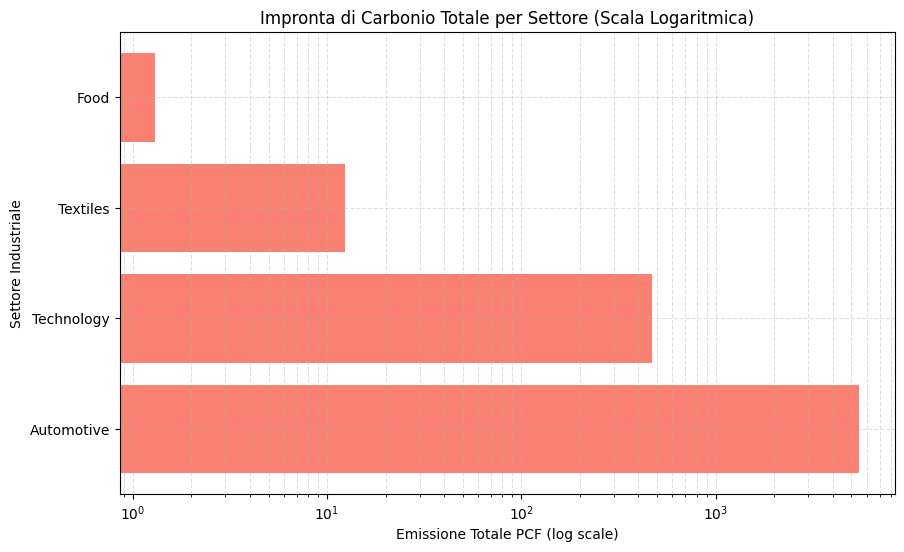

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Usiamo i nomi corretti del tuo DataFrame 'carbon_emissions_by_industry'
plt.barh(risultato['industry_group'], 
         risultato['total_carbon_footprint'], 
         color='salmon')

# TRUCCO: Impostiamo la scala logaritmica sull'asse X
plt.xscale('log')

plt.title('Impronta di Carbonio Totale per Settore (Scala Logaritmica)')
plt.xlabel('Emissione Totale PCF (log scale)')
plt.ylabel('Settore Industriale')
plt.grid(True, which="both", ls="--", alpha=0.4) # Grid più fitta per i logaritmi

plt.show()



Interpretazione: Il grafico mostra chiaramente che, sebbene ci siano aziende in ogni settore, l'impatto dell'industria dei trasporti è enormemente superiore agli altri, un dato chiave per qualsiasi analisi di sostenibilità.